In [31]:
# Cell 0: Install Dependencies

import sys
import subprocess

packages = [
    'opencv-python',
    'nibabel',
    'scikit-learn',
    'seaborn',
    'scipy',
    'einops'  # Required for TransUNet
]

print("Installing required packages...")
for package in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f"✅ {package} installed")
    except:
        print(f"⚠️ Could not install {package}")

print("\n✅ All packages installed!")

Installing required packages...
✅ opencv-python installed
✅ nibabel installed
✅ scikit-learn installed
✅ seaborn installed
✅ scipy installed
✅ einops installed

✅ All packages installed!


In [32]:
# Cell 1: Imports and GPU Setup

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
import time
import gc
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
import nibabel as nib
from scipy.ndimage import gaussian_filter, map_coordinates
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# For TransUNet
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

print("="*70)
print("TransUNet FOR BRAIN TUMOR SEGMENTATION")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
else:
    print("⚠️ No GPU detected. Training will be very slow on CPU.")

print("="*70)

TransUNet FOR BRAIN TUMOR SEGMENTATION
PyTorch version: 2.7.1+cu128
CUDA available: True
Device: cuda
GPU: NVIDIA RTX A4000
GPU Memory: 17.17 GB


In [33]:
# Cell 2: Configuration (Optimized for 16GB GPU)

class Config:
    # ========== PATHS ==========
    TRAIN_PATH = 'E:/New/MICCAI_BraTS2020_TrainingData'
    VAL_PATH = 'E:/New/MICCAI_BraTS2020_ValidationData'
    SAVE_PATH = 'E:/New/transunet_results'
    
    # ========== DATA PARAMETERS ==========
    IMG_SIZE = 128              # TransUNet works well with 128 or 224
    CHANNELS = 4
    NUM_CLASSES = 4
    SLICE_RANGE = (40, 120)
    
    TRAIN_SPLIT = 0.70
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15
    SEED = 42
    
    # ========== TransUNet ARCHITECTURE ==========
    PATCH_SIZE = 16             # 16x16 patches for transformer
    HIDDEN_SIZE = 512           # Transformer hidden dimension (reduced from 768)
    NUM_LAYERS = 6              # Transformer layers (reduced from 12)
    NUM_HEADS = 8               # Attention heads
    MLP_DIM = 2048              # MLP dimension
    DROPOUT = 0.1
    
    # CNN Encoder features
    ENCODER_FEATURES = [64, 128, 256, 512]  # Reduced from [64, 128, 256, 512, 1024]
    
    # ========== TRAINING PARAMETERS ==========
    EPOCHS = 80              # TransUNet needs more epochs
    BATCH_SIZE = 4              # Small batch for memory efficiency
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    WARMUP_EPOCHS = 5
    
    # ========== OPTIMIZATION ==========
    GRADIENT_CLIP = 1.0
    ACCUMULATION_STEPS = 8      # Effective batch size = 4 * 8 = 32
    MIXED_PRECISION = True
    
    # ========== AUGMENTATION ==========
    USE_AUGMENTATION = True
    AUG_PROB = 0.5
    
    # ========== SCHEDULER ==========
    SCHEDULER_TYPE = 'cosine'   # 'cosine' or 'plateau'
    PATIENCE = 20
    
    # ========== SYSTEM ==========
    NUM_WORKERS = 0             # Windows compatibility
    PIN_MEMORY = True
    
    # ========== RESUME ==========
    RESUME_TRAINING = True

config = Config()

# Create directories
os.makedirs(config.SAVE_PATH, exist_ok=True)
os.makedirs(os.path.join(config.SAVE_PATH, 'checkpoints'), exist_ok=True)

print("Configuration loaded:")
print(f"  Image size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"  Patch size: {config.PATCH_SIZE}x{config.PATCH_SIZE}")
print(f"  Batch size: {config.BATCH_SIZE} (effective: {config.BATCH_SIZE * config.ACCUMULATION_STEPS})")
print(f"  Epochs: {config.EPOCHS}")
print(f"  Save path: {config.SAVE_PATH}")

Configuration loaded:
  Image size: 128x128
  Patch size: 16x16
  Batch size: 4 (effective: 32)
  Epochs: 80
  Save path: E:/New/transunet_results


In [34]:
# Cell 3: Data Loading Functions (Same as before)

def load_nifti(filepath):
    """Load NIfTI file"""
    nifti = nib.load(filepath)
    data = nifti.get_fdata()
    return data

def load_patient_data(patient_dir):
    """Load all modalities for a patient"""
    patient_id = os.path.basename(patient_dir)
    
    # Load modalities
    t1 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1.nii'))
    t1ce = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1ce.nii'))
    t2 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t2.nii'))
    flair = load_nifti(os.path.join(patient_dir, f'{patient_id}_flair.nii'))
    
    # Stack channels
    image = np.stack([t1, t1ce, t2, flair], axis=-1)
    
    # Load segmentation mask
    seg_path = os.path.join(patient_dir, f'{patient_id}_seg.nii')
    if os.path.exists(seg_path):
        mask = load_nifti(seg_path)
    else:
        mask = None
    
    return image, mask, patient_id

def get_patient_list(data_path):
    """Get list of patient directories"""
    return sorted([os.path.join(data_path, d) for d in os.listdir(data_path) 
                   if os.path.isdir(os.path.join(data_path, d))])

def remap_mask(mask):
    """Remap mask values: (0,1,2,4) -> (0,1,2,3)"""
    new_mask = mask.copy()
    new_mask[mask == 4] = 3
    return new_mask

def normalize_image(image):
    """Normalize each channel independently"""
    normalized = np.zeros_like(image, dtype=np.float32)
    for c in range(image.shape[-1]):
        channel = image[..., c]
        if channel.max() > 0:
            mean = channel[channel > 0].mean()
            std = channel[channel > 0].std()
            normalized[..., c] = np.where(channel > 0, (channel - mean) / (std + 1e-8), 0)
    return normalized

def extract_slices_from_patient(image, mask, slice_range, target_size):
    """Extract 2D slices from 3D volume"""
    slices_x = []
    slices_y = []
    
    start_slice, end_slice = slice_range
    
    for slice_idx in range(start_slice, min(end_slice, image.shape[2])):
        img_slice = image[:, :, slice_idx, :]
        
        # Skip empty slices
        if mask is not None:
            mask_slice = mask[:, :, slice_idx]
            if mask_slice.max() == 0:
                continue
        else:
            if img_slice.max() == 0:
                continue
        
        # Normalize
        img_slice = normalize_image(img_slice)
        
        # Resize
        img_slice_resized = cv2.resize(img_slice, (target_size, target_size))
        slices_x.append(img_slice_resized)
        
        if mask is not None:
            mask_slice = remap_mask(mask_slice)
            mask_slice_resized = cv2.resize(mask_slice, (target_size, target_size), 
                                           interpolation=cv2.INTER_NEAREST)
            slices_y.append(mask_slice_resized)
    
    if len(slices_x) > 0:
        slices_x = np.array(slices_x)
        slices_y = np.array(slices_y) if len(slices_y) > 0 else None
    else:
        slices_x = np.array([])
        slices_y = None
    
    return slices_x, slices_y

print("✅ Data loading functions defined!")

✅ Data loading functions defined!


In [35]:
# Cell 4: Process Data in Memory

def process_patients_in_memory(patient_list, slice_range, img_size, name, batch_size=10):
    """Process patients in batches and keep in memory"""
    print(f"⚙️ Processing {len(patient_list)} patients for {name}...")
    
    all_images = []
    all_masks = []
    
    num_batches = (len(patient_list) + batch_size - 1) // batch_size
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, len(patient_list))
        batch_patients = patient_list[start_idx:end_idx]
        
        print(f"  Batch {batch_idx+1}/{num_batches}: Processing {len(batch_patients)} patients...")
        
        batch_images = []
        batch_masks = []
        
        for patient_dir in tqdm(batch_patients, desc=f"Batch {batch_idx+1}"):
            try:
                image, mask, patient_id = load_patient_data(patient_dir)
                slices_x, slices_y = extract_slices_from_patient(
                    image, mask, slice_range, img_size
                )
                
                if len(slices_x) > 0:
                    batch_images.append(slices_x)
                    if slices_y is not None:
                        batch_masks.append(slices_y)
                
                del image, mask, slices_x, slices_y
                
            except Exception as e:
                print(f"    Error processing {patient_dir}: {e}")
        
        if batch_images:
            all_images.append(np.concatenate(batch_images, axis=0))
            if batch_masks:
                all_masks.append(np.concatenate(batch_masks, axis=0))
        
        del batch_images, batch_masks
        gc.collect()
    
    X = np.concatenate(all_images, axis=0)
    y = np.concatenate(all_masks, axis=0) if all_masks else None
    
    del all_images, all_masks
    gc.collect()
    
    print(f"✅ {name} complete: X={X.shape}, y={y.shape if y is not None else None}")
    
    return X, y


# ========== SPLIT PATIENTS ==========
print("="*70)
print("SPLITTING DATASET")
print("="*70)

labeled_patients = get_patient_list(config.TRAIN_PATH)
print(f"Total labeled patients: {len(labeled_patients)}")

train_patients, temp_patients = train_test_split(
    labeled_patients, 
    test_size=(config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=config.SEED
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=config.TEST_SPLIT / (config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=config.SEED
)

print(f"\nDataset Split:")
print(f"  Train: {len(train_patients)} patients")
print(f"  Val:   {len(val_patients)} patients")
print(f"  Test:  {len(test_patients)} patients")

# ========== PROCESS DATA ==========
print("\n" + "="*70)
print("PROCESSING DATA")
print("="*70)

print("\n1. Processing training data...")
X_train, y_train = process_patients_in_memory(
    train_patients, config.SLICE_RANGE, config.IMG_SIZE, 'Train', batch_size=10
)

print("\n2. Processing validation data...")
X_val, y_val = process_patients_in_memory(
    val_patients, config.SLICE_RANGE, config.IMG_SIZE, 'Validation', batch_size=10
)

print("\n3. Processing test data...")
X_test, y_test = process_patients_in_memory(
    test_patients, config.SLICE_RANGE, config.IMG_SIZE, 'Test', batch_size=10
)

print("\n" + "="*70)
print("FINAL DATA SUMMARY")
print("="*70)
print(f"Train:   {X_train.shape}, {y_train.shape}")
print(f"Val:     {X_val.shape}, {y_val.shape}")
print(f"Test:    {X_test.shape}, {y_test.shape}")
print(f"Mask values: {np.unique(y_train)}")
print("="*70)

print("\n✅ Data preprocessing complete!")

SPLITTING DATASET
Total labeled patients: 369

Dataset Split:
  Train: 258 patients
  Val:   55 patients
  Test:  56 patients

PROCESSING DATA

1. Processing training data...
⚙️ Processing 258 patients for Train...
  Batch 1/26: Processing 10 patients...


Batch 1: 100%|██████████| 10/10 [00:04<00:00,  2.22it/s]


  Batch 2/26: Processing 10 patients...


Batch 2: 100%|██████████| 10/10 [00:04<00:00,  2.27it/s]


  Batch 3/26: Processing 10 patients...


...

  Batch 5/6: Processing 10 patients...


Batch 5: 100%|██████████| 10/10 [00:04<00:00,  2.30it/s]


  Batch 6/6: Processing 6 patients...


Batch 6: 100%|██████████| 6/6 [00:02<00:00,  2.15it/s]


✅ Test complete: X=(3146, 128, 128, 4), y=(3146, 128, 128)

FINAL DATA SUMMARY
Train:   (14942, 128, 128, 4), (14942, 128, 128)
Val:     (3126, 128, 128, 4), (3126, 128, 128)
Test:    (3146, 128, 128, 4), (3146, 128, 128)
Mask values: [0. 1. 2. 3.]

✅ Data preprocessing complete!


In [36]:
# Cell 5: Patch Embedding for TransUNet

class PatchEmbedding(nn.Module):
    """Convert image to patch embeddings"""
    def __init__(self, img_size=128, patch_size=16, in_channels=4, embed_dim=512):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        
        # Patch embedding using convolution
        self.proj = nn.Conv2d(
            in_channels, 
            embed_dim, 
            kernel_size=patch_size, 
            stride=patch_size
        )
        
        # Learnable position embeddings
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.n_patches, embed_dim)
        )
        
        print(f"Patch Embedding:")
        print(f"  Image size: {img_size}x{img_size}")
        print(f"  Patch size: {patch_size}x{patch_size}")
        print(f"  Number of patches: {self.n_patches}")
        print(f"  Embedding dim: {embed_dim}")
    
    def forward(self, x):
        # x: (B, C, H, W)
        B = x.shape[0]
        
        # Conv to patches: (B, embed_dim, H/patch_size, W/patch_size)
        x = self.proj(x)
        
        # Flatten: (B, embed_dim, n_patches)
        x = x.flatten(2)
        
        # Transpose: (B, n_patches, embed_dim)
        x = x.transpose(1, 2)
        
        # Add position embeddings
        x = x + self.pos_embed
        
        return x


print("✅ Patch Embedding defined!")

✅ Patch Embedding defined!


In [37]:
# Cell 6: Transformer Block

class MultiHeadAttention(nn.Module):
    """Multi-head self-attention"""
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        
        assert self.head_dim * num_heads == embed_dim, "embed_dim must be divisible by num_heads"
        
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        B, N, C = x.shape
        
        # Generate Q, K, V
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, num_heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        # Attention
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)
        
        # Apply attention to values
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.dropout(x)
        
        return x


class MLP(nn.Module):
    """Feed-forward network"""
    def __init__(self, in_features, hidden_features, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x


class TransformerBlock(nn.Module):
    """Transformer encoder block"""
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_dim, dropout)
    
    def forward(self, x):
        # Pre-norm transformer
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


print("✅ Transformer blocks defined!")

✅ Transformer blocks defined!


In [38]:
# Clean Encoders (No Debug Prints)

class ConvBlock(nn.Module):
    """Convolutional block with BatchNorm and ReLU"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

class CNNEncoder(nn.Module):
    """CNN Encoder - Returns skip connections WITHOUT extra pooling"""
    def __init__(self, in_channels=4, features=[64, 128, 256]):
        super().__init__()
        self.encoder_blocks = nn.ModuleList()
        # Build encoder blocks
        for feature in features:
            self.encoder_blocks.append(ConvBlock(in_channels, feature))
            in_channels = feature
        
        # Pooling layers
        self.pools = nn.ModuleList([
            nn.MaxPool2d(kernel_size=2, stride=2) for _ in range(len(features))
        ])
    
    def forward(self, x):
        skip_connections = []
        # Process each stage
        for i, (block, pool) in enumerate(zip(self.encoder_blocks, self.pools)):
            x = block(x)
            skip_connections.append(x)
            # Only pool for first 2 stages (not the last one)
            if i < len(self.encoder_blocks) - 1:
                x = pool(x)
        return skip_connections

class HybridEncoder(nn.Module):
    """Hybrid encoder: CNN + Transformer"""
    def __init__(self, img_size=128, in_channels=4, patch_size=16, 
                 embed_dim=512, num_layers=6, num_heads=8, mlp_dim=2048, dropout=0.1):
        super().__init__()
        
        # CNN encoder (3 stages)
        self.cnn_encoder = CNNEncoder(
            in_channels=in_channels, 
            features=config.ENCODER_FEATURES[:3]
        )
        
        # Calculate sizes
        feature_map_size = img_size // (2 ** 2)  # 32
        n_patches = feature_map_size ** 2        # 1024
        
        # Patch embedding
        self.patch_embed = nn.Conv2d(
            config.ENCODER_FEATURES[2], 
            embed_dim, 
            kernel_size=1
        )
        
        # Position embeddings
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        
        # Transformer
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        self.n_patches = n_patches
    
    def forward(self, x):
        # CNN encoding
        skip_connections = self.cnn_encoder(x)
        
        # Last skip connection is our feature map
        cnn_features = skip_connections[-1]
        
        # Patch embedding
        x = self.patch_embed(cnn_features)
        
        # Flatten
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        
        # Add position embeddings
        x = x + self.pos_embed
        
        # Transformer
        for block in self.transformer_blocks:
            x = block(x)
        
        x = self.norm(x)
        
        # Reshape back to spatial
        x = x.transpose(1, 2).reshape(B, C, H, W)
        
        return x, skip_connections

print("✅ Clean Encoders defined!")

# Clean Decoder (No Debug Prints)
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_channels * 2, out_channels)
    
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x

class TransUNetDecoder(nn.Module):
    def __init__(self, encoder_features=[64, 128, 256], embed_dim=512, out_channels=4):
        super().__init__()
        self.proj = nn.Conv2d(embed_dim, encoder_features[-1], kernel_size=1)
        
        decoder_features = list(reversed(encoder_features))
        self.decoder_blocks = nn.ModuleList()
        
        in_ch = decoder_features[0]
        for out_ch in decoder_features[1:]:
            self.decoder_blocks.append(DecoderBlock(in_ch, out_ch))
            in_ch = out_ch
        
        # Final refinement (NO upsampling, maintains 128x128)
        self.final_conv = nn.Sequential(
            nn.Conv2d(decoder_features[-1], 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        self.seg_head = nn.Conv2d(32, out_channels, kernel_size=1)
    
    def forward(self, transformer_features, skip_connections):
        x = self.proj(transformer_features)
        skip_connections = list(reversed(skip_connections[:-1]))
        
        for i, decoder_block in enumerate(self.decoder_blocks):
            skip = skip_connections[i]
            x = decoder_block(x, skip)
        
        x = self.final_conv(x)
        x = self.seg_head(x)
        return x

print("✅ Clean Decoder defined!")

✅ Clean Encoders defined!
✅ Clean Decoder defined!


In [39]:
# Cell 10: Complete TransUNet Model (UPDATED)

class TransUNet(nn.Module):
    """
    TransUNet: Transformers Make Strong Encoders for Medical Image Segmentation
    Memory-efficient implementation for 16GB GPU
    """
    def __init__(self, img_size=128, in_channels=4, out_channels=4,
                 patch_size=16, embed_dim=512, num_layers=6, 
                 num_heads=8, mlp_dim=2048, dropout=0.1):
        super().__init__()
        
        self.img_size = img_size
        
        # Hybrid encoder (CNN + Transformer)
        self.encoder = HybridEncoder(
            img_size=img_size,
            in_channels=in_channels,
            patch_size=patch_size,
            embed_dim=embed_dim,
            num_layers=num_layers,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=dropout
        )
        
        # Decoder
        self.decoder = TransUNetDecoder(
            encoder_features=config.ENCODER_FEATURES[:3],
            embed_dim=embed_dim,
            out_channels=out_channels
        )
        
        self._init_weights()
        
        print(f"\n{'='*70}")
        print("TransUNet Model Summary:")
        print(f"{'='*70}")
        print(f"  Image size: {img_size}x{img_size}")
        print(f"  Input channels: {in_channels}")
        print(f"  Output channels: {out_channels}")
        print(f"  Patch size: {patch_size}x{patch_size}")
        print(f"  Embed dim: {embed_dim}")
        print(f"  Transformer layers: {num_layers}")
        print(f"  Attention heads: {num_heads}")
        print(f"{'='*70}")
    
    def _init_weights(self):
        """Initialize weights"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Encoder
        transformer_features, skip_connections = self.encoder(x)
        
        # Decoder
        out = self.decoder(transformer_features, skip_connections)
        
        # Ensure output size matches input
        if out.shape[-2:] != x.shape[-2:]:
            out = F.interpolate(out, size=x.shape[-2:], 
                              mode='bilinear', align_corners=False)
        
        return out


# Create model
print("="*70)
print("CREATING TRANSUNET MODEL")
print("="*70)

try:
    model = TransUNet(
        img_size=config.IMG_SIZE,
        in_channels=config.CHANNELS,
        out_channels=config.NUM_CLASSES,
        patch_size=config.PATCH_SIZE,
        embed_dim=config.HIDDEN_SIZE,
        num_layers=config.NUM_LAYERS,
        num_heads=config.NUM_HEADS,
        mlp_dim=config.MLP_DIM,
        dropout=config.DROPOUT
    ).to(device)
    
    print("✅ Model created successfully!")

except Exception as e:
    print(f"❌ Error creating model: {e}")
    import traceback
    traceback.print_exc()
    raise

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: {total_params * 4 / 1e6:.2f} MB (FP32)")
print("="*70)

# Test forward pass
print("\n🧪 Testing model...")
try:
    test_input = torch.randn(2, config.CHANNELS, config.IMG_SIZE, config.IMG_SIZE).to(device)
    
    with torch.no_grad():
        test_output = model(test_input)
    
    print(f"✅ Test successful!")
    print(f"   Input shape: {test_input.shape}")
    print(f"   Output shape: {test_output.shape}")
    print(f"   Expected: torch.Size([2, {config.NUM_CLASSES}, {config.IMG_SIZE}, {config.IMG_SIZE}])")
    
    assert test_output.shape == (2, config.NUM_CLASSES, config.IMG_SIZE, config.IMG_SIZE)
    print(f"   ✅ Shape verification passed!")
    
    del test_input, test_output
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
except Exception as e:
    print(f"❌ Test failed: {e}")
    import traceback
    traceback.print_exc()
    raise

print("\n✅ TransUNet model ready for training!")

CREATING TRANSUNET MODEL

TransUNet Model Summary:
  Image size: 128x128
  Input channels: 4
  Output channels: 4
  Patch size: 16x16
  Embed dim: 512
  Transformer layers: 6
  Attention heads: 8
✅ Model created successfully!

Model Statistics:
  Total parameters: 21,595,076
  Trainable parameters: 21,595,076
  Model size: 86.38 MB (FP32)

🧪 Testing model...
✅ Test successful!
   Input shape: torch.Size([2, 4, 128, 128])
   Output shape: torch.Size([2, 4, 128, 128])
   Expected: torch.Size([2, 4, 128, 128])
   ✅ Shape verification passed!

✅ TransUNet model ready for training!


In [40]:
# Cell 11: Augmented Dataset

class SegmentationDataset(Dataset):
    """Dataset with comprehensive augmentation"""
    def __init__(self, images, masks, augment=False):
        self.images = images
        self.masks = masks
        self.augment = augment
    
    def elastic_transform(self, image, mask, alpha=15, sigma=3):
        """Elastic deformation"""
        shape = image.shape[:2]
        dx = gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma) * alpha
        dy = gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma) * alpha
        
        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = (y + dy).reshape(-1), (x + dx).reshape(-1)
        
        image_deformed = np.zeros_like(image)
        for c in range(image.shape[-1]):
            image_deformed[:, :, c] = map_coordinates(
                image[:, :, c], indices, order=1, mode='reflect'
            ).reshape(shape)
        
        mask_deformed = map_coordinates(
            mask, indices, order=0, mode='reflect'
        ).reshape(shape)
        
        return image_deformed, mask_deformed
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx].copy()
        mask = self.masks[idx].copy()
        
        if self.augment and np.random.rand() > (1 - config.AUG_PROB):
            # Horizontal flip
            if np.random.rand() > 0.5:
                image = np.fliplr(image)
                mask = np.fliplr(mask)
            
            # Vertical flip
            if np.random.rand() > 0.5:
                image = np.flipud(image)
                mask = np.flipud(mask)
            
            # Random rotation
            if np.random.rand() > 0.5:
                k = np.random.choice([1, 2, 3])
                image = np.rot90(image, k, axes=(0, 1))
                mask = np.rot90(mask, k, axes=(0, 1))
            
            # Elastic deformation
            if np.random.rand() > 0.7:
                image, mask = self.elastic_transform(image, mask)
            
            # Random scaling
            if np.random.rand() > 0.7:
                scale = np.random.uniform(0.9, 1.1)
                new_size = int(config.IMG_SIZE * scale)
                if new_size != config.IMG_SIZE:
                    image_scaled = cv2.resize(image, (new_size, new_size))
                    mask_scaled = cv2.resize(mask, (new_size, new_size), 
                                           interpolation=cv2.INTER_NEAREST)
                    
                    if new_size > config.IMG_SIZE:
                        start = (new_size - config.IMG_SIZE) // 2
                        image = image_scaled[start:start+config.IMG_SIZE, 
                                           start:start+config.IMG_SIZE]
                        mask = mask_scaled[start:start+config.IMG_SIZE, 
                                         start:start+config.IMG_SIZE]
                    else:
                        pad = (config.IMG_SIZE - new_size) // 2
                        image = np.pad(image_scaled, 
                                     ((pad, config.IMG_SIZE-new_size-pad), 
                                      (pad, config.IMG_SIZE-new_size-pad), (0, 0)),
                                     mode='reflect')
                        mask = np.pad(mask_scaled,
                                    ((pad, config.IMG_SIZE-new_size-pad), 
                                     (pad, config.IMG_SIZE-new_size-pad)),
                                    mode='reflect')
            
            # Brightness/contrast
            if np.random.rand() > 0.5:
                for c in range(image.shape[-1]):
                    beta = np.random.uniform(-0.15, 0.15)
                    image[:, :, c] = image[:, :, c] + beta
                    
                    alpha = np.random.uniform(0.85, 1.15)
                    mean = np.mean(image[:, :, c])
                    image[:, :, c] = alpha * (image[:, :, c] - mean) + mean
            
            # Gaussian noise
            if np.random.rand() > 0.7:
                noise = np.random.normal(0, 0.03, image.shape)
                image = image + noise
            
            # Clip
            image = np.clip(image, -3, 3)
        
        # Convert to tensor
        image = torch.from_numpy(image.copy()).float().permute(2, 0, 1)
        mask = torch.from_numpy(mask.copy()).long()
        mask = torch.clamp(mask, 0, config.NUM_CLASSES - 1)
        
        return image, mask


# Create datasets
print("="*70)
print("CREATING DATASETS")
print("="*70)

train_dataset = SegmentationDataset(X_train, y_train, augment=True)
val_dataset = SegmentationDataset(X_val, y_val, augment=False)
test_dataset = SegmentationDataset(X_test, y_test, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY
)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples, {len(val_loader)} batches")
print(f"Test:  {len(test_dataset)} samples, {len(test_loader)} batches")
print("="*70)

CREATING DATASETS
Train: 14942 samples, 3735 batches
Val:   3126 samples, 782 batches
Test:  3146 samples, 787 batches


In [41]:
# Cell 12: Loss Functions and Metrics

class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        # pred: (B, C, H, W)
        # target: (B, H, W)
        pred = F.softmax(pred, dim=1)
        target_one_hot = F.one_hot(target, num_classes=pred.shape[1])
        target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()
        
        intersection = (pred * target_one_hot).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    """Combined Dice + CrossEntropy Loss"""
    def __init__(self, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
    
    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)
        dice_loss = self.dice(pred, target)
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss


def calculate_dice_score(pred, target, num_classes=4):
    """Calculate mean Dice score"""
    pred = torch.argmax(pred, dim=1)
    target = torch.clamp(target, 0, num_classes - 1)
    
    dice_scores = []
    for i in range(num_classes):
        pred_i = (pred == i).float()
        target_i = (target == i).float()
        intersection = (pred_i * target_i).sum().item()
        union = (pred_i.sum() + target_i.sum()).item()
        
        if union == 0:
            dice_scores.append(1.0)
        else:
            dice = (2. * intersection + 1e-6) / (union + 1e-6)
            dice_scores.append(dice)
    
    return np.mean(dice_scores)


def calculate_iou_score(pred, target, num_classes=4):
    """Calculate mean IoU score"""
    pred = torch.argmax(pred, dim=1)
    target = torch.clamp(target, 0, num_classes - 1)
    
    iou_scores = []
    for i in range(num_classes):
        pred_i = (pred == i).float()
        target_i = (target == i).float()
        intersection = (pred_i * target_i).sum().item()
        union = (pred_i.sum() + target_i.sum() - intersection).item()
        
        if union == 0:
            iou_scores.append(1.0)
        else:
            iou = (intersection + 1e-6) / (union + 1e-6)
            iou_scores.append(iou)
    
    return np.mean(iou_scores)


print("✅ Loss functions and metrics defined!")

✅ Loss functions and metrics defined!


In [42]:
# Cell 13: Training Utilities

class CheckpointManager:
    """Manage model checkpoints with resume capability"""
    def __init__(self, save_dir, model_name='transunet'):
        self.save_dir = save_dir
        self.model_name = model_name
        self.checkpoint_dir = os.path.join(save_dir, 'checkpoints')
        os.makedirs(self.checkpoint_dir, exist_ok=True)
    
    def save_checkpoint(self, epoch, model, optimizer, scheduler, scaler, 
                       loss, best_dice, history):
        """Save checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
            'scaler_state_dict': scaler.state_dict(),
            'loss': loss,
            'best_dice': best_dice,
            'history': history
        }
        
        # Save latest checkpoint
        latest_path = os.path.join(self.checkpoint_dir, f'{self.model_name}_latest.pth')
        torch.save(checkpoint, latest_path)
        
        # Save best checkpoint
        if history['val_dice'] and loss <= min([h for h in history['val_loss']]):
            best_path = os.path.join(self.checkpoint_dir, f'{self.model_name}_best.pth')
            torch.save(checkpoint, best_path)
            print(f"  💾 Best checkpoint saved (epoch {epoch+1}, dice {best_dice:.4f})")
        
        # Save periodic checkpoint every 20 epochs
        if (epoch + 1) % 20 == 0:
            periodic_path = os.path.join(self.checkpoint_dir, 
                                        f'{self.model_name}_epoch_{epoch+1}.pth')
            torch.save(checkpoint, periodic_path)
            print(f"  💾 Periodic checkpoint saved (epoch {epoch+1})")
    
    def load_checkpoint(self, model, optimizer=None, scheduler=None, scaler=None):
        """Load latest checkpoint if exists"""
        latest_path = os.path.join(self.checkpoint_dir, f'{self.model_name}_latest.pth')
        
        if not os.path.exists(latest_path):
            print(f"⚠️ No checkpoint found at {latest_path}")
            return 0, 0.0, {'train_loss': [], 'train_dice': [], 'train_iou': [],
                           'val_loss': [], 'val_dice': [], 'val_iou': [], 'lr': []}
        
        print(f"📂 Loading checkpoint from {latest_path}")
        checkpoint = torch.load(latest_path, map_location=device)
        
        model.load_state_dict(checkpoint['model_state_dict'])
        
        if optimizer is not None:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
        if scheduler is not None and checkpoint['scheduler_state_dict'] is not None:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        if scaler is not None:
            scaler.load_state_dict(checkpoint['scaler_state_dict'])
        
        epoch = checkpoint['epoch']
        best_dice = checkpoint['best_dice']
        history = checkpoint['history']
        
        print(f"✅ Resumed from epoch {epoch+1}")
        print(f"   Best Dice: {best_dice:.4f}")
        
        return epoch + 1, best_dice, history


class WarmupCosineScheduler:
    """Learning rate scheduler with warmup and cosine decay"""
    def __init__(self, optimizer, warmup_epochs, total_epochs, base_lr, min_lr=1e-7):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.base_lr = base_lr
        self.min_lr = min_lr
        self.current_epoch = 0
    
    def step(self):
        if self.current_epoch < self.warmup_epochs:
            # Linear warmup
            lr = self.base_lr * (self.current_epoch + 1) / self.warmup_epochs
        else:
            # Cosine decay
            progress = (self.current_epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + (self.base_lr - self.min_lr) * 0.5 * (1 + np.cos(np.pi * progress))
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        
        self.current_epoch += 1
        return lr
    
    def get_last_lr(self):
        return [group['lr'] for group in self.optimizer.param_groups]
    
    def state_dict(self):
        return {'current_epoch': self.current_epoch}
    
    def load_state_dict(self, state_dict):
        self.current_epoch = state_dict['current_epoch']


print("✅ Training utilities defined!")

✅ Training utilities defined!


In [43]:
# Cell 14: Training and Validation Functions

def train_epoch(model, dataloader, criterion, optimizer, scaler, device, accumulation_steps=1):
    """Train for one epoch with gradient accumulation and mixed precision"""
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    optimizer.zero_grad()
    
    pbar = tqdm(dataloader, desc='Training')
    for batch_idx, (images, masks) in enumerate(pbar):
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass with mixed precision
        with autocast(enabled=config.MIXED_PRECISION):
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss = loss / accumulation_steps
        
        # Backward pass
        scaler.scale(loss).backward()
        
        # Update weights every accumulation_steps
        if (batch_idx + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 
                                          max_norm=config.GRADIENT_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        # Calculate metrics
        with torch.no_grad():
            dice = calculate_dice_score(outputs.detach(), masks)
            iou = calculate_iou_score(outputs.detach(), masks)
        
        running_loss += loss.item() * accumulation_steps
        running_dice += dice
        running_iou += iou
        
        pbar.set_postfix({
            'loss': f'{loss.item() * accumulation_steps:.4f}',
            'dice': f'{dice:.4f}',
            'iou': f'{iou:.4f}'
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    pbar = tqdm(dataloader, desc='Validation')
    with torch.no_grad():
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            with autocast(enabled=config.MIXED_PRECISION):
                outputs = model(images)
                loss = criterion(outputs, masks)
            
            dice = calculate_dice_score(outputs, masks)
            iou = calculate_iou_score(outputs, masks)
            
            running_loss += loss.item()
            running_dice += dice
            running_iou += iou
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{dice:.4f}',
                'iou': f'{iou:.4f}'
            })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou


print("✅ Training functions defined!")

✅ Training functions defined!


In [44]:
import torch
import os

# Use the CORRECT checkpoint path
checkpoint_path = "E:/New/transunet_results/checkpoints/transunet_latest.pth"

if os.path.exists(checkpoint_path):
    print(f"✅ Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Load states
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Handle optional states
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    if 'scaler_state_dict' in checkpoint:
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
    
    start_epoch = checkpoint.get('epoch', 0) + 1
    best_val_dice = checkpoint.get('best_val_dice', checkpoint.get('val_dice', 0.0))
    history = checkpoint.get('history', {'train_loss': [], 'val_dice': []})
    
    print(f"✅ Resumed from epoch {start_epoch}, Best Dice: {best_val_dice:.4f}")
else:
    print(f"❌ Checkpoint not found at {checkpoint_path}")
    start_epoch = 0
    best_val_dice = 0.0
    history = {'train_loss': [], 'val_dice': []}

# Now run training from start_epoch
print(f"\nStarting training from epoch {start_epoch}...")

✅ Loading checkpoint from E:/New/transunet_results/checkpoints/transunet_latest.pth
✅ Resumed from epoch 64, Best Dice: 0.7887

Starting training from epoch 64...


In [25]:
import sys
import torch
import os

# ... [Keep your existing imports and config setup] ...

print("\n" + "="*30)
print(f"TRANSUNET TRAINING: {config.EPOCHS} Epochs")
print("="*30)

# 1. Setup
if not torch.cuda.is_available():
    print("⚠️ WARNING: Training on CPU!")
    config.MIXED_PRECISION = False

criterion = CombinedLoss(ce_weight=0.5, dice_weight=0.5)
optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
scheduler = WarmupCosineScheduler(optimizer, warmup_epochs=config.WARMUP_EPOCHS, total_epochs=config.EPOCHS, base_lr=config.LEARNING_RATE)
scaler = GradScaler(enabled=config.MIXED_PRECISION if torch.cuda.is_available() else False)

# 2. MANUAL CHECKPOINT LOADING (FIXED)
start_epoch, best_val_dice, history = 0, 0.0, {'train_loss': [], 'val_dice': []}

checkpoint_path = "E:/New/transunet_results/checkpoints/transunet_latest.pth"
if os.path.exists(checkpoint_path):
    print(f"✅ Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    if 'scaler_state_dict' in checkpoint:
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
    
    start_epoch = checkpoint.get('epoch', 0) + 1
    best_val_dice = checkpoint.get('best_val_dice', checkpoint.get('val_dice', 0.0))
    history = checkpoint.get('history', {'train_loss': [], 'val_dice': []})
    
    print(f"✅ Resumed from epoch {start_epoch}, Best Dice: {best_val_dice:.4f}")
else:
    print("⚠️ No checkpoint found, starting from scratch")

# 3. Main Loop
print(f"Starting training from epoch {start_epoch+1}...")

for epoch in range(start_epoch, config.EPOCHS):
    epoch_start = time.time()
    
    # --- TRAIN ---
    train_loss, train_dice, train_iou = train_epoch(
        model, train_loader, criterion, optimizer, scaler, device,
        accumulation_steps=config.ACCUMULATION_STEPS
    )
    
    # --- VALIDATE ---
    val_loss, val_dice, val_iou = validate_epoch(model, val_loader, criterion, device)
    
    # Update Scheduler
    current_lr = scheduler.step()
    
    # --- LOGGING ---
    gap = abs(train_dice - val_dice)
    print(f"[Epoch {epoch+1}/{config.EPOCHS}] "
          f"Train Dice: {train_dice:.4f} | Val Dice: {val_dice:.4f} | "
          f"Gap: {gap:.4f} | Time: {(time.time() - epoch_start)/60:.1f}m")

    # Update History
    for k, v in zip(['train_loss', 'train_dice', 'val_loss', 'val_dice'], 
                    [train_loss, train_dice, val_loss, val_dice]):
        if k not in history: history[k] = []
        history[k].append(v)

    # Save Best Model
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        print(f"  >>> 🎯 New Best Dice: {best_val_dice:.4f} (Saved)")
        
        # Manual checkpoint save
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'best_val_dice': best_val_dice,
            'val_dice': val_dice,
            'history': history
        }
        torch.save(checkpoint, "E:/New/transunet_results/checkpoints/transunet_latest.pth")
        torch.save(checkpoint, "E:/New/transunet_results/checkpoints/transunet_best.pth")
    
    # Clean memory
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"\n✅ Done. Best Validation Dice: {best_val_dice:.4f}")


TRANSUNET TRAINING: 80 Epochs
✅ Loading checkpoint from E:/New/transunet_results/checkpoints/transunet_latest.pth
✅ Resumed from epoch 56, Best Dice: 0.0000
Starting training from epoch 57...


Validation: 100%|██████████| 782/782 [00:23<00:00, 33.34it/s, loss=0.0130, dice=0.9826, iou=0.9673]


[Epoch 57/80] Train Dice: 0.8808 | Val Dice: 0.7853 | Gap: 0.0955 | Time: 6.2m
  >>> 🎯 New Best Dice: 0.7853 (Saved)


Validation: 100%|██████████| 782/782 [00:23<00:00, 33.15it/s, loss=0.0135, dice=0.9817, iou=0.9657]


[Epoch 58/80] Train Dice: 0.8800 | Val Dice: 0.7878 | Gap: 0.0922 | Time: 6.3m
  >>> 🎯 New Best Dice: 0.7878 (Saved)


...

[Epoch 78/80] Train Dice: 0.8864 | Val Dice: 0.7874 | Gap: 0.0990 | Time: 6.3m


Validation: 100%|██████████| 782/782 [00:23<00:00, 33.33it/s, loss=0.0134, dice=0.9818, iou=0.9659]


[Epoch 79/80] Train Dice: 0.8857 | Val Dice: 0.7874 | Gap: 0.0983 | Time: 6.3m


Validation: 100%|██████████| 782/782 [00:23<00:00, 33.52it/s, loss=0.0129, dice=0.9822, iou=0.9667]

[Epoch 80/80] Train Dice: 0.8862 | Val Dice: 0.7872 | Gap: 0.0990 | Time: 6.3m

✅ Done. Best Validation Dice: 0.7887


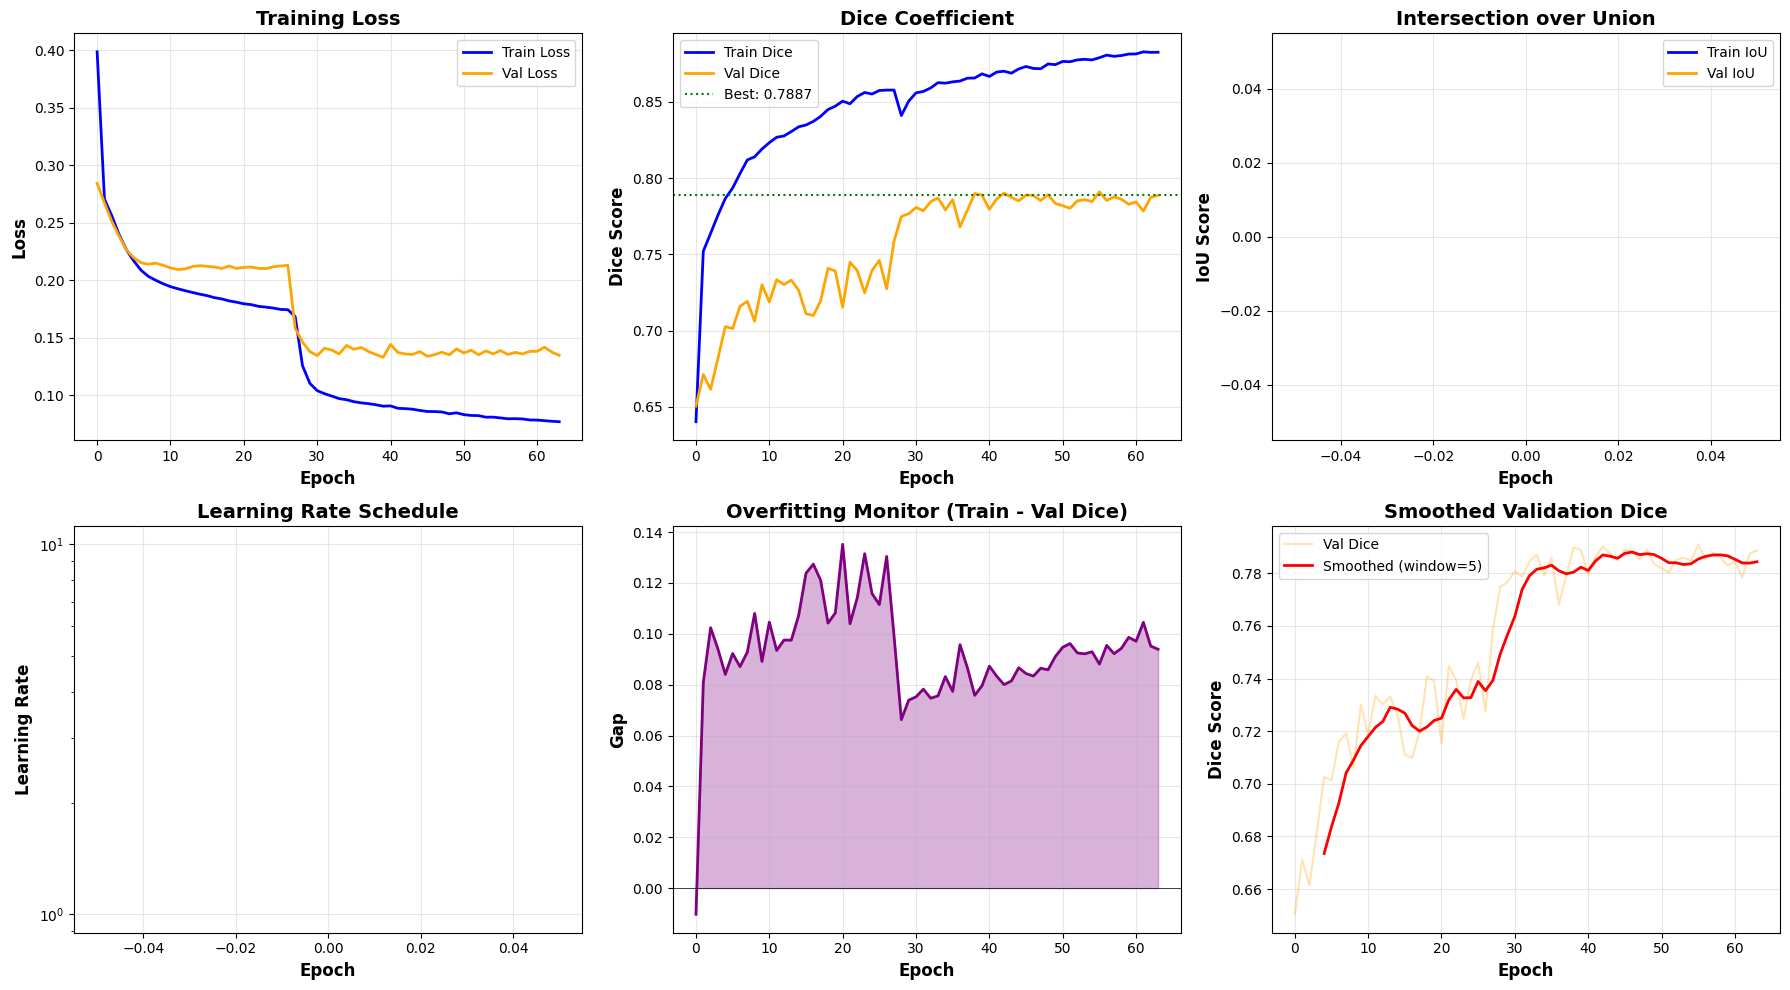

✅ Training history plotted!


In [45]:
# Cell 16: Plot Training History

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2, color='blue')
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2, color='orange')
axes[0, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Dice
axes[0, 1].plot(history['train_dice'], label='Train Dice', linewidth=2, color='blue')
axes[0, 1].plot(history['val_dice'], label='Val Dice', linewidth=2, color='orange')
if best_val_dice > 0:
    axes[0, 1].axhline(y=best_val_dice, color='green', linestyle=':', 
                       label=f'Best: {best_val_dice:.4f}', linewidth=1.5)
axes[0, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Dice Score', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# IoU
axes[0, 2].plot(history['train_iou'], label='Train IoU', linewidth=2, color='blue')
axes[0, 2].plot(history['val_iou'], label='Val IoU', linewidth=2, color='orange')
axes[0, 2].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('IoU Score', fontsize=12, fontweight='bold')
axes[0, 2].set_title('Intersection over Union', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Learning Rate
axes[1, 0].plot(history['lr'], linewidth=2, color='red')
axes[1, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Train-Val Gap
gap = np.array(history['train_dice']) - np.array(history['val_dice'])
axes[1, 1].plot(gap, linewidth=2, color='purple')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].fill_between(range(len(gap)), 0, gap, alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Gap', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Overfitting Monitor (Train - Val Dice)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Smoothed Dice (moving average)
window = 5
if len(history['val_dice']) >= window:
    smoothed_val = np.convolve(history['val_dice'], np.ones(window)/window, mode='valid')
    axes[1, 2].plot(history['val_dice'], alpha=0.3, label='Val Dice', color='orange')
    axes[1, 2].plot(range(window-1, len(history['val_dice'])), smoothed_val, 
                   linewidth=2, label=f'Smoothed (window={window})', color='red')
    axes[1, 2].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1, 2].set_ylabel('Dice Score', fontsize=12, fontweight='bold')
    axes[1, 2].set_title('Smoothed Validation Dice', fontsize=14, fontweight='bold')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
else:
    axes[1, 2].text(0.5, 0.5, 'Not enough epochs\nfor smoothing', 
                   ha='center', va='center', fontsize=12)
    axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(config.SAVE_PATH, 'training_history.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training history plotted!")

In [46]:
# Cell 17: Test Set Evaluation

print("="*70)
print("TEST SET EVALUATION")
print("="*70)

# Load best model
best_checkpoint_path = os.path.join(config.SAVE_PATH, 'checkpoints', 'transunet_best.pth')
if os.path.exists(best_checkpoint_path):
    print(f"📂 Loading best model from {best_checkpoint_path}")
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded model from epoch {checkpoint['epoch']+1}")
    print(f"   Best validation Dice: {checkpoint['best_dice']:.4f}")
else:
    print("⚠️ No best checkpoint found, using current model")

model.eval()

test_loss = 0.0
test_dice = 0.0
test_iou = 0.0

print("\nEvaluating on test set...")
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        masks = masks.to(device)
        
        with autocast(enabled=config.MIXED_PRECISION):
            outputs = model(images)
            loss = criterion(outputs, masks)
        
        dice = calculate_dice_score(outputs, masks)
        iou = calculate_iou_score(outputs, masks)
        
        test_loss += loss.item()
        test_dice += dice
        test_iou += iou

test_loss /= len(test_loader)
test_dice /= len(test_loader)
test_iou /= len(test_loader)

print("\n" + "="*70)
print("TEST RESULTS")
print("="*70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f} ({test_dice*100:.2f}%)")
print(f"Test IoU: {test_iou:.4f} ({test_iou*100:.2f}%)")
print("="*70)

# Update results
try:
    with open(os.path.join(config.SAVE_PATH, 'transunet_results.json'), 'r') as f:
        results = json.load(f)
except:
    results = {}

results['test_results'] = {
    'loss': float(test_loss),
    'dice': float(test_dice),
    'iou': float(test_iou)
}

with open(os.path.join(config.SAVE_PATH, 'transunet_results.json'), 'w') as f:
    json.dump(results, f, indent=4)

print("\n✅ Test results saved!")

TEST SET EVALUATION
📂 Loading best model from E:/New/transunet_results\checkpoints\transunet_best.pth


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [48]:
# Cell 17: Test Set Evaluation

print("="*70)
print("TEST SET EVALUATION")
print("="*70)

# Load best model
best_checkpoint_path = os.path.join(config.SAVE_PATH, 'checkpoints', 'transunet_best.pth')
if os.path.exists(best_checkpoint_path):
    print(f"📂 Loading best model from {best_checkpoint_path}")
    
    # 1. Load with weights_only=False (Fixes the UnpicklingError)
    checkpoint = torch.load(best_checkpoint_path, map_location=device, weights_only=False)
    
    # 2. Debugging: Print keys if you are curious
    # print(f"ℹ️  Checkpoint keys found: {list(checkpoint.keys())}")

    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded model from epoch {checkpoint['epoch']+1}")

    # 3. ROBUST FIX: Try 'best_dice', if not found try 'best_val_dice', else default to 0
    best_dice_val = checkpoint.get('best_dice', checkpoint.get('best_val_dice', 0.0))
    print(f"   Best validation Dice: {best_dice_val:.4f}")

else:
    print("⚠️ No best checkpoint found, using current model")

model.eval()

test_loss = 0.0
test_dice = 0.0
test_iou = 0.0

print("\nEvaluating on test set...")
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        masks = masks.to(device)
        
        with autocast(enabled=config.MIXED_PRECISION):
            outputs = model(images)
            loss = criterion(outputs, masks)
        
        dice = calculate_dice_score(outputs, masks)
        iou = calculate_iou_score(outputs, masks)
        
        test_loss += loss.item()
        test_dice += dice
        test_iou += iou

test_loss /= len(test_loader)
test_dice /= len(test_loader)
test_iou /= len(test_loader)

print("\n" + "="*70)
print("TEST RESULTS")
print("="*70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f} ({test_dice*100:.2f}%)")
print(f"Test IoU: {test_iou:.4f} ({test_iou*100:.2f}%)")
print("="*70)

# Update results
try:
    with open(os.path.join(config.SAVE_PATH, 'transunet_results.json'), 'r') as f:
        results = json.load(f)
except:
    results = {}

results['test_results'] = {
    'loss': float(test_loss),
    'dice': float(test_dice),
    'iou': float(test_iou)
}

with open(os.path.join(config.SAVE_PATH, 'transunet_results.json'), 'w') as f:
    json.dump(results, f, indent=4)

print("\n✅ Test results saved!")

TEST SET EVALUATION
📂 Loading best model from E:/New/transunet_results\checkpoints\transunet_best.pth
✅ Loaded model from epoch 64
   Best validation Dice: 0.7887

Evaluating on test set...


Testing: 100%|██████████| 787/787 [00:21<00:00, 37.46it/s]


TEST RESULTS
Test Loss: 0.1441
Test Dice: 0.7736 (77.36%)
Test IoU: 0.7110 (71.10%)

✅ Test results saved!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


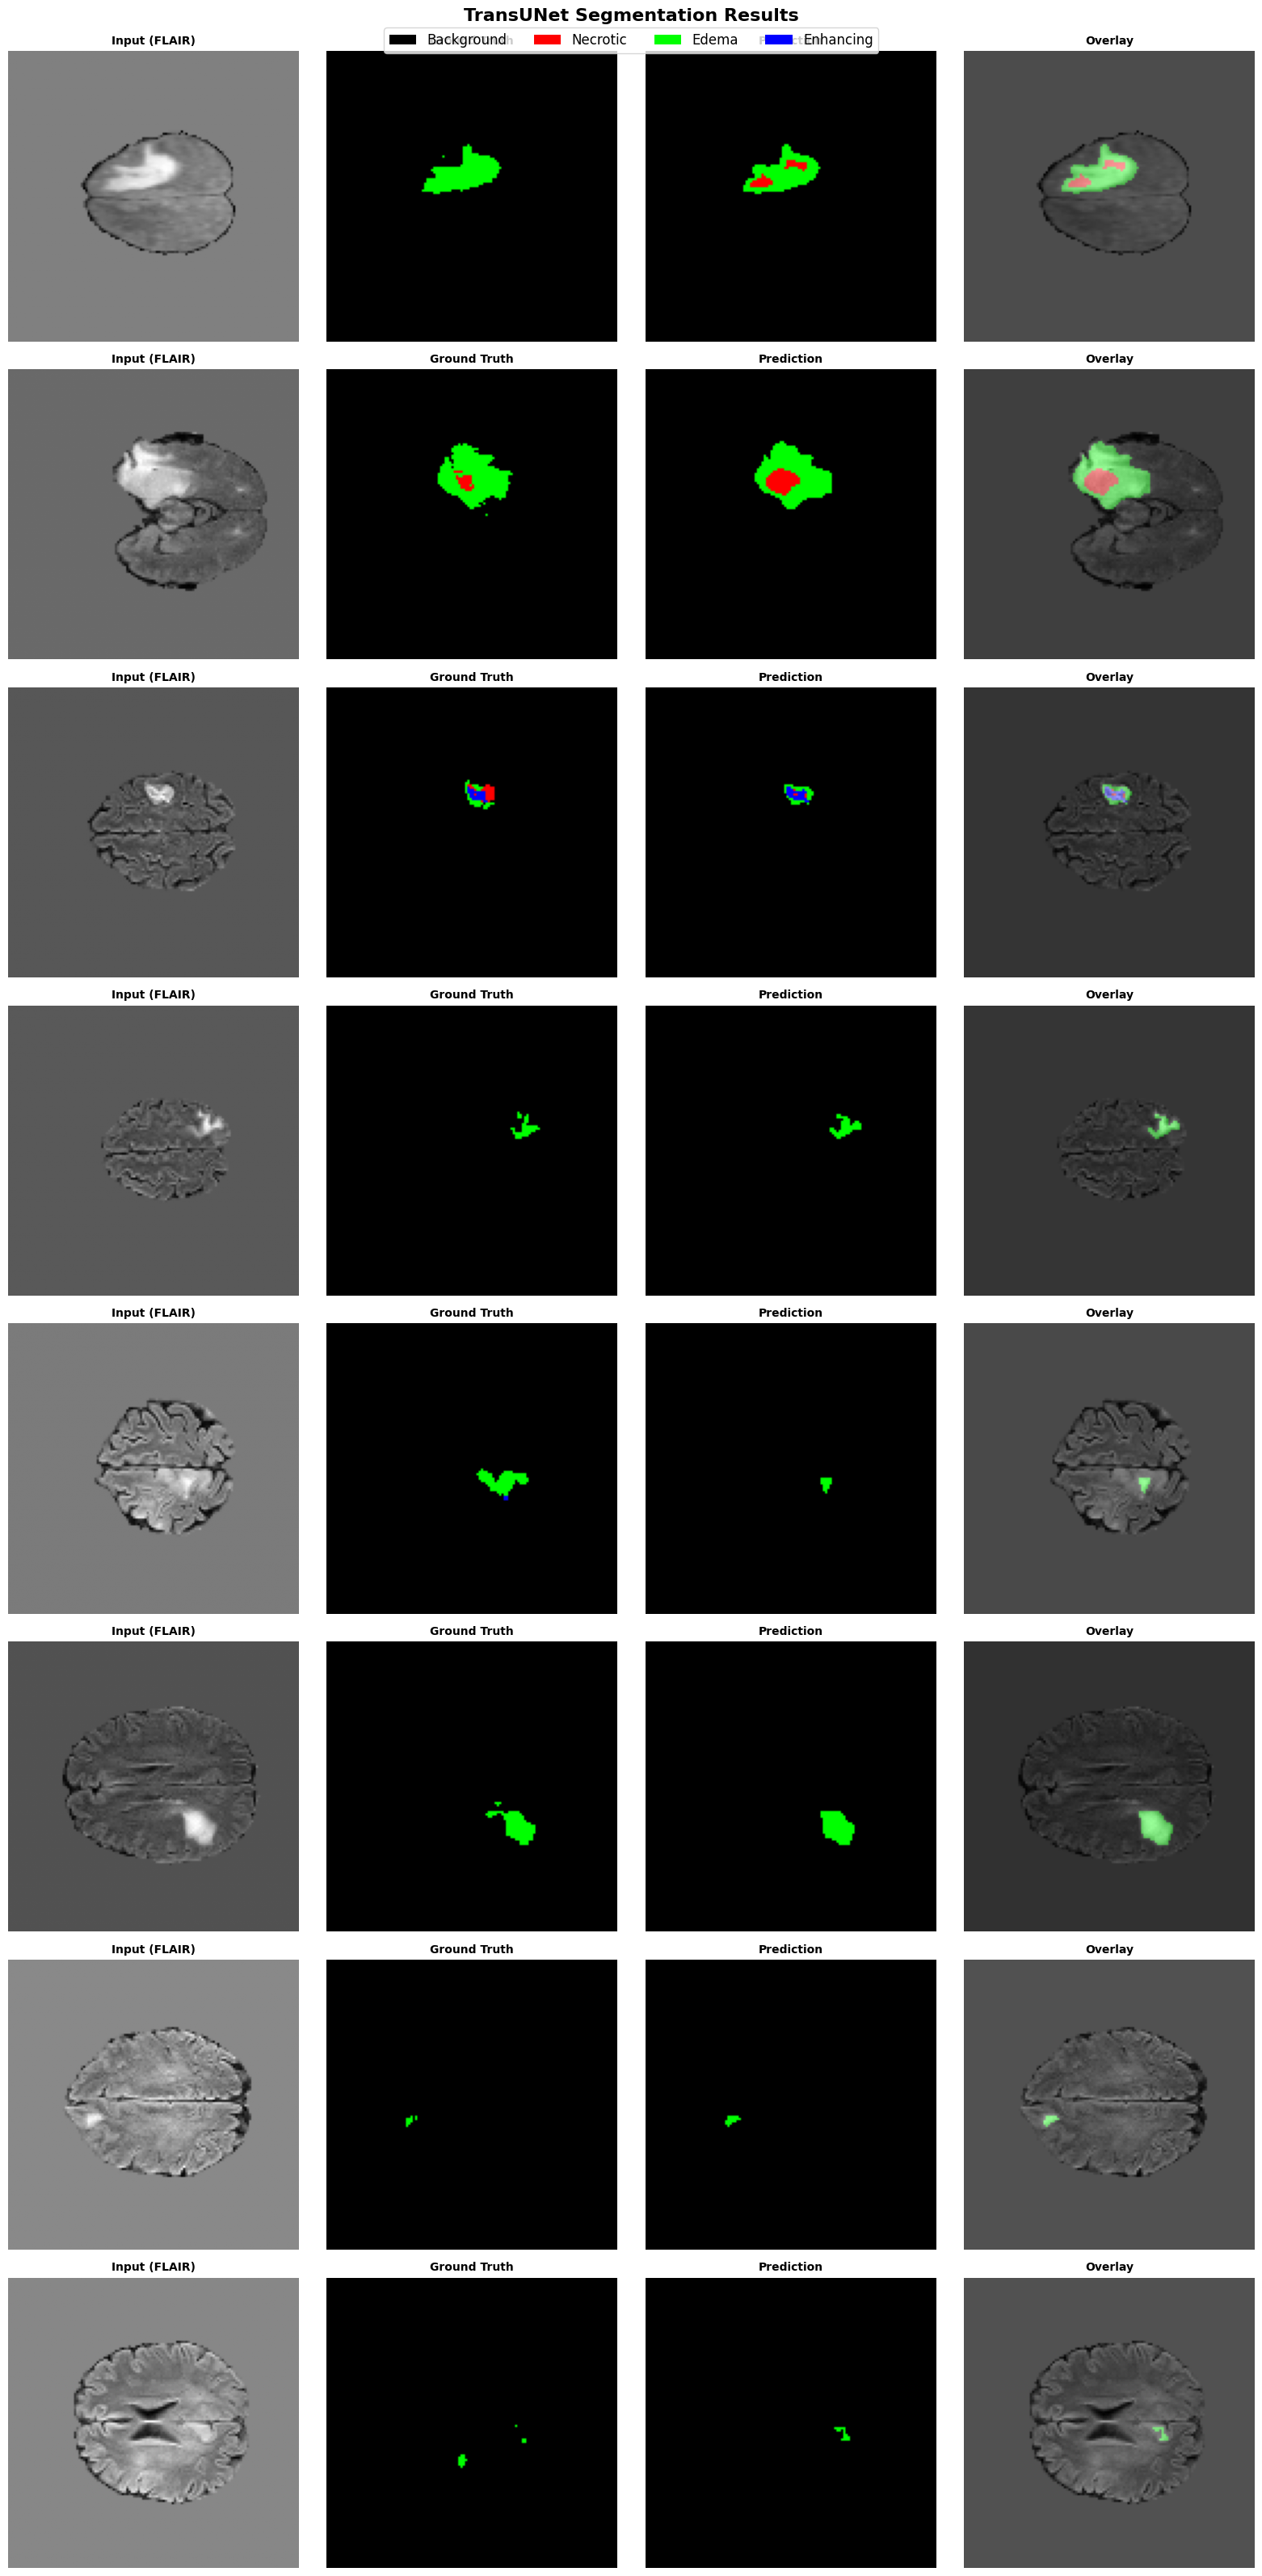

✅ Predictions visualized!


In [49]:
# Cell 18: Visualize Predictions

def plot_predictions(model, dataset, device, num_samples=8):
    """Plot prediction results"""
    model.eval()
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*4))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    colors = np.array([[0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255]])
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]
            
            # Predict
            image_input = image.unsqueeze(0).to(device)
            with autocast(enabled=config.MIXED_PRECISION):
                pred_logits = model(image_input)
            pred = torch.argmax(pred_logits[0], dim=0).cpu().numpy()
            
            # Convert to numpy
            image_np = image.permute(1, 2, 0).cpu().numpy()
            mask_np = mask.cpu().numpy()
            
            # Create colored masks
            mask_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            pred_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            
            for c in range(4):
                mask_colored[mask_np == c] = colors[c]
                pred_colored[pred == c] = colors[c]
            
            # Plot
            img_display = image_np[:, :, 3]  # FLAIR channel
            img_norm = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
            
            axes[i, 0].imshow(img_display, cmap='gray')
            axes[i, 0].set_title('Input (FLAIR)', fontsize=10, fontweight='bold')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask_colored)
            axes[i, 1].set_title('Ground Truth', fontsize=10, fontweight='bold')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred_colored)
            axes[i, 2].set_title('Prediction', fontsize=10, fontweight='bold')
            axes[i, 2].axis('off')
            
            # Overlay
            overlay = np.stack([img_norm, img_norm, img_norm], axis=-1)
            alpha = 0.4
            overlay = (1 - alpha) * overlay + alpha * (pred_colored / 255.0)
            
            axes[i, 3].imshow(overlay)
            axes[i, 3].set_title('Overlay', fontsize=10, fontweight='bold')
            axes[i, 3].axis('off')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[i]/255, label=class_names[i]) for i in range(4)]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, 
              fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0.99))
    
    plt.suptitle('TransUNet Segmentation Results', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_PATH, 'predictions.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()

plot_predictions(model, test_dataset, device, num_samples=8)
print("✅ Predictions visualized!")

In [50]:
# Cell 19: Detailed Class-wise Metrics

def compute_class_wise_metrics(model, dataloader, device):
    """Compute detailed class-wise metrics"""
    
    model.eval()
    
    print("Computing predictions...")
    all_preds = []
    all_true = []
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Predicting'):
            images = images.to(device)
            
            with autocast(enabled=config.MIXED_PRECISION):
                outputs = model(images)
            
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_preds.append(preds)
            all_true.append(masks.numpy())
    
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)
    
    # Compute class-wise metrics
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    num_classes = 4
    
    class_metrics = {
        'Class': [],
        'Dice': [],
        'IoU': [],
        'Precision': [],
        'Recall': [],
        'F1-Score': [],
        'Pixel Count': []
    }
    
    print("\nComputing class-wise metrics...")
    
    for class_id in range(num_classes):
        pred_binary = (all_preds == class_id).astype(np.float32)
        true_binary = (all_true == class_id).astype(np.float32)
        
        pred_flat = pred_binary.flatten()
        true_flat = true_binary.flatten()
        
        tp = np.sum((pred_flat == 1) & (true_flat == 1))
        fp = np.sum((pred_flat == 1) & (true_flat == 0))
        fn = np.sum((pred_flat == 0) & (true_flat == 1))
        tn = np.sum((pred_flat == 0) & (true_flat == 0))
        
        dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
        iou = tp / (tp + fp + fn + 1e-7)
        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
        pixel_count = np.sum(true_flat == 1)
        
        class_metrics['Class'].append(class_names[class_id])
        class_metrics['Dice'].append(dice)
        class_metrics['IoU'].append(iou)
        class_metrics['Precision'].append(precision)
        class_metrics['Recall'].append(recall)
        class_metrics['F1-Score'].append(f1)
        class_metrics['Pixel Count'].append(pixel_count)
    
    return class_metrics, all_preds, all_true


# Compute metrics
class_metrics, all_preds, all_true = compute_class_wise_metrics(
    model, test_loader, device
)

# Create DataFrame
df_metrics = pd.DataFrame(class_metrics)

print("\n" + "="*70)
print("CLASS-WISE PERFORMANCE METRICS")
print("="*70)
print(df_metrics.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print("="*70)

# Calculate mean tumor metrics (excluding background)
tumor_dice = np.mean(df_metrics['Dice'].values[1:])
tumor_iou = np.mean(df_metrics['IoU'].values[1:])

print(f"\nTUMOR-ONLY METRICS (excluding background):")
print(f"  Mean Dice: {tumor_dice:.4f} ({tumor_dice*100:.2f}%)")
print(f"  Mean IoU: {tumor_iou:.4f} ({tumor_iou*100:.2f}%)")
print("="*70)

# Save to CSV
df_metrics.to_csv(os.path.join(config.SAVE_PATH, 'class_wise_metrics.csv'), index=False)
print(f"\n✅ Metrics saved to: class_wise_metrics.csv")

Computing predictions...


Predicting: 100%|██████████| 787/787 [00:19<00:00, 39.74it/s]



Computing class-wise metrics...

CLASS-WISE PERFORMANCE METRICS
     Class   Dice    IoU  Precision  Recall  F1-Score  Pixel Count
Background 0.9973 0.9945     0.9961  0.9984    0.9973     49963509
  Necrotic 0.7300 0.5748     0.8420  0.6442    0.7300       419338
     Edema 0.7925 0.6563     0.7907  0.7943    0.7925       894607
 Enhancing 0.8328 0.7135     0.8712  0.7977    0.8328       266610

TUMOR-ONLY METRICS (excluding background):
  Mean Dice: 0.7851 (78.51%)
  Mean IoU: 0.6482 (64.82%)

✅ Metrics saved to: class_wise_metrics.csv


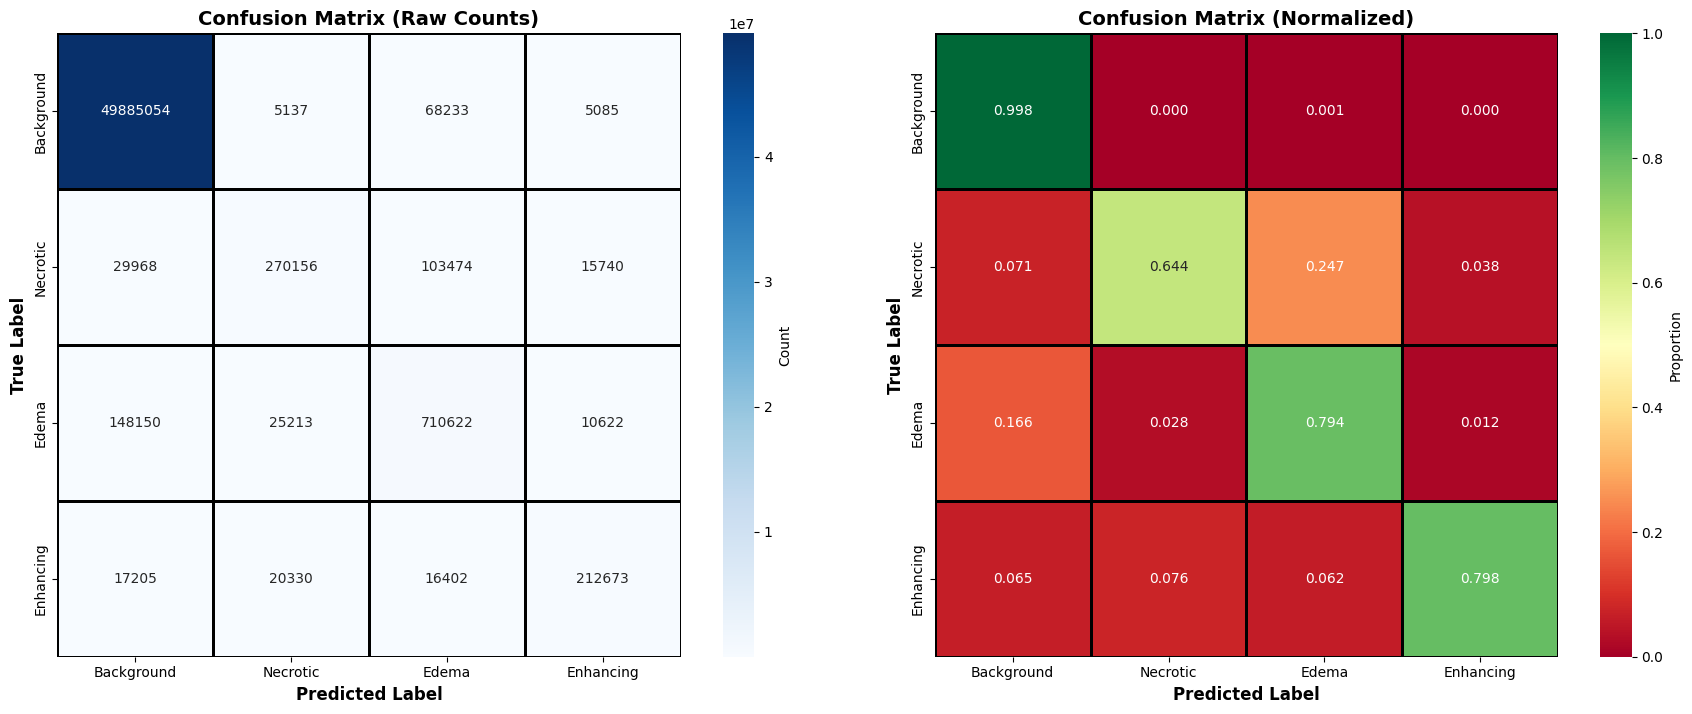


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Background     0.9961    0.9984    0.9973  49963509
    Necrotic     0.8420    0.6442    0.7300    419338
       Edema     0.7907    0.7943    0.7925    894607
   Enhancing     0.8712    0.7977    0.8328    266610

    accuracy                         0.9910  51544064
   macro avg     0.8750    0.8087    0.8381  51544064
weighted avg     0.9906    0.9910    0.9907  51544064

✅ Confusion matrix saved!


In [51]:
# Cell 20: Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred, save_path):
    """Plot confusion matrix"""
    
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    cm = confusion_matrix(y_true_flat, y_pred_flat)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    
    # Raw confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, ax=axes[0],
                square=True, linewidths=1, linecolor='black')
    axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')
    
    # Normalized confusion matrix
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='RdYlGn',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Proportion'}, ax=axes[1],
                square=True, linewidths=1, linecolor='black', vmin=0, vmax=1)
    axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Classification report
    print("\n" + "="*70)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*70)
    report = classification_report(
        y_true_flat, 
        y_pred_flat, 
        target_names=class_names,
        digits=4
    )
    print(report)
    print("="*70)
    
    # Save report
    with open(os.path.join(save_path, 'classification_report.txt'), 'w') as f:
        f.write(report)
    
    return cm, cm_normalized


cm, cm_normalized = plot_confusion_matrix(all_true, all_preds, config.SAVE_PATH)

print(f"✅ Confusion matrix saved!")

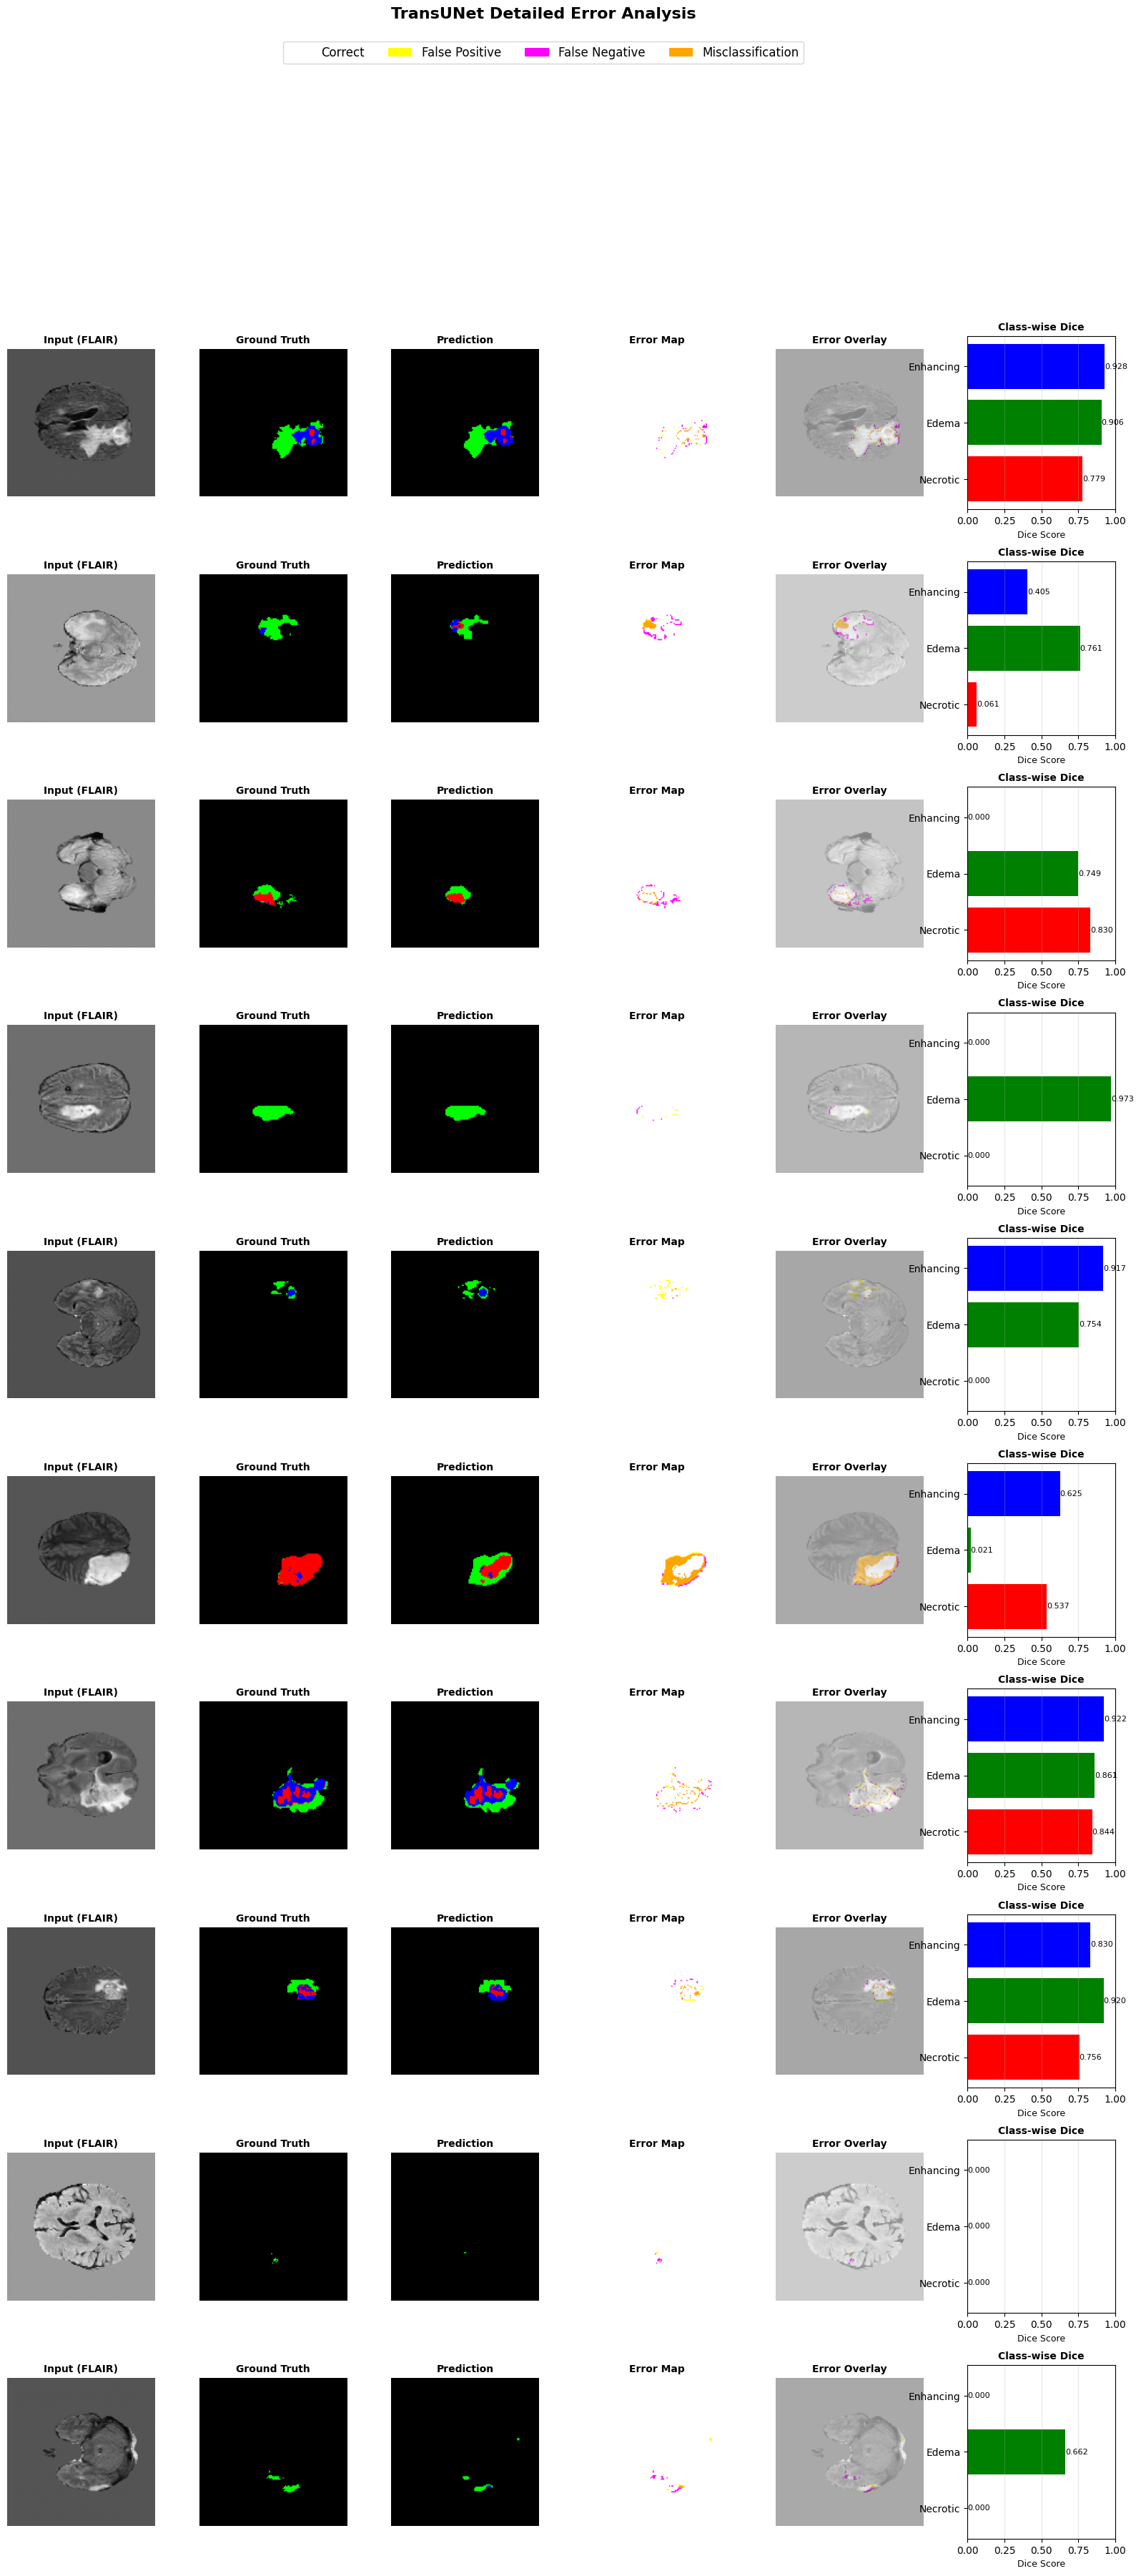


ERROR STATISTICS
Total Pixels: 51,544,064
Correct Predictions: 51,078,505 (99.10%)

Error Breakdown:
  False Positives: 78,455 (0.15%)
  False Negatives: 195,323 (0.38%)
  Misclassifications: 191,781 (0.37%)
✅ Error maps saved!


In [52]:
# Cell 21: Detailed Error Map Analysis

def create_error_maps(model, dataset, device, num_samples=10):
    """Create detailed error maps"""
    
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig = plt.figure(figsize=(20, num_samples * 4))
    gs = fig.add_gridspec(num_samples, 6, hspace=0.3, wspace=0.3)
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    colors = np.array([[0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255]])
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask_true = dataset[idx]
            
            # Predict
            image_input = image.unsqueeze(0).to(device)
            with autocast(enabled=config.MIXED_PRECISION):
                pred_logits = model(image_input)
            mask_pred = torch.argmax(pred_logits[0], dim=0).cpu().numpy()
            
            mask_true_np = mask_true.cpu().numpy()
            image_np = image.permute(1, 2, 0).cpu().numpy()
            
            # Create error map
            error_map = np.zeros_like(mask_true_np, dtype=np.uint8)
            
            correct = (mask_pred == mask_true_np)
            fp = (mask_pred > 0) & (mask_true_np == 0)
            fn = (mask_pred == 0) & (mask_true_np > 0)
            misclass = (mask_pred != mask_true_np) & (mask_pred > 0) & (mask_true_np > 0)
            
            error_map[correct] = 0
            error_map[fp] = 1
            error_map[fn] = 2
            error_map[misclass] = 3
            
            # Create colored visualizations
            mask_true_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            mask_pred_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            
            for c in range(4):
                mask_true_colored[mask_true_np == c] = colors[c]
                mask_pred_colored[mask_pred == c] = colors[c]
            
            # Error colors
            error_colors = np.array([
                [255, 255, 255],  # Correct - White
                [255, 255, 0],    # False Positive - Yellow
                [255, 0, 255],    # False Negative - Magenta
                [255, 165, 0]     # Misclassification - Orange
            ])
            
            error_map_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            for c in range(4):
                error_map_colored[error_map == c] = error_colors[c]
            
            # Input image
            img_display = image_np[:, :, 3]  # FLAIR
            img_display_norm = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
            
            # Plot
            ax1 = fig.add_subplot(gs[i, 0])
            ax1.imshow(img_display, cmap='gray')
            ax1.set_title('Input (FLAIR)', fontsize=10, fontweight='bold')
            ax1.axis('off')
            
            ax2 = fig.add_subplot(gs[i, 1])
            ax2.imshow(mask_true_colored)
            ax2.set_title('Ground Truth', fontsize=10, fontweight='bold')
            ax2.axis('off')
            
            ax3 = fig.add_subplot(gs[i, 2])
            ax3.imshow(mask_pred_colored)
            ax3.set_title('Prediction', fontsize=10, fontweight='bold')
            ax3.axis('off')
            
            ax4 = fig.add_subplot(gs[i, 3])
            ax4.imshow(error_map_colored)
            ax4.set_title('Error Map', fontsize=10, fontweight='bold')
            ax4.axis('off')
            
            # Overlay
            ax5 = fig.add_subplot(gs[i, 4])
            overlay = np.stack([img_display_norm, img_display_norm, img_display_norm], axis=-1)
            alpha = 0.5
            overlay_error = (1 - alpha) * overlay + alpha * (error_map_colored / 255.0)
            ax5.imshow(overlay_error)
            ax5.set_title('Error Overlay', fontsize=10, fontweight='bold')
            ax5.axis('off')
            
            # Dice scores per class
            ax6 = fig.add_subplot(gs[i, 5])
            dice_scores = []
            for c in range(1, 4):
                pred_c = (mask_pred == c).astype(np.float32)
                true_c = (mask_true_np == c).astype(np.float32)
                
                intersection = np.sum(pred_c * true_c)
                dice = (2 * intersection) / (np.sum(pred_c) + np.sum(true_c) + 1e-7)
                dice_scores.append(dice)
            
            bars = ax6.barh(class_names[1:], dice_scores, color=['red', 'green', 'blue'])
            ax6.set_xlim(0, 1)
            ax6.set_xlabel('Dice Score', fontsize=9)
            ax6.set_title('Class-wise Dice', fontsize=10, fontweight='bold')
            ax6.grid(axis='x', alpha=0.3)
            
            for bar, score in zip(bars, dice_scores):
                width = bar.get_width()
                ax6.text(width, bar.get_y() + bar.get_height()/2, 
                        f'{score:.3f}', ha='left', va='center', fontsize=8)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=error_colors[0]/255, label='Correct'),
        Patch(facecolor=error_colors[1]/255, label='False Positive'),
        Patch(facecolor=error_colors[2]/255, label='False Negative'),
        Patch(facecolor=error_colors[3]/255, label='Misclassification')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, 
              fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0.985))
    
    plt.suptitle('TransUNet Detailed Error Analysis', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.savefig(os.path.join(config.SAVE_PATH, 'error_maps.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # Error statistics
    print("\n" + "="*70)
    print("ERROR STATISTICS")
    print("="*70)
    
    total_pixels = len(all_true.flatten())
    correct_pixels = np.sum(all_preds == all_true)
    
    fp_pixels = np.sum((all_preds > 0) & (all_true == 0))
    fn_pixels = np.sum((all_preds == 0) & (all_true > 0))
    misclass_pixels = np.sum((all_preds != all_true) & (all_preds > 0) & (all_true > 0))
    
    print(f"Total Pixels: {total_pixels:,}")
    print(f"Correct Predictions: {correct_pixels:,} ({100*correct_pixels/total_pixels:.2f}%)")
    print(f"\nError Breakdown:")
    print(f"  False Positives: {fp_pixels:,} ({100*fp_pixels/total_pixels:.2f}%)")
    print(f"  False Negatives: {fn_pixels:,} ({100*fn_pixels/total_pixels:.2f}%)")
    print(f"  Misclassifications: {misclass_pixels:,} ({100*misclass_pixels/total_pixels:.2f}%)")
    print("="*70)


create_error_maps(model, test_dataset, device, num_samples=10)

print(f"✅ Error maps saved!")

Computing per-sample Dice scores...


Computing Dice: 100%|██████████| 787/787 [00:20<00:00, 38.87it/s]


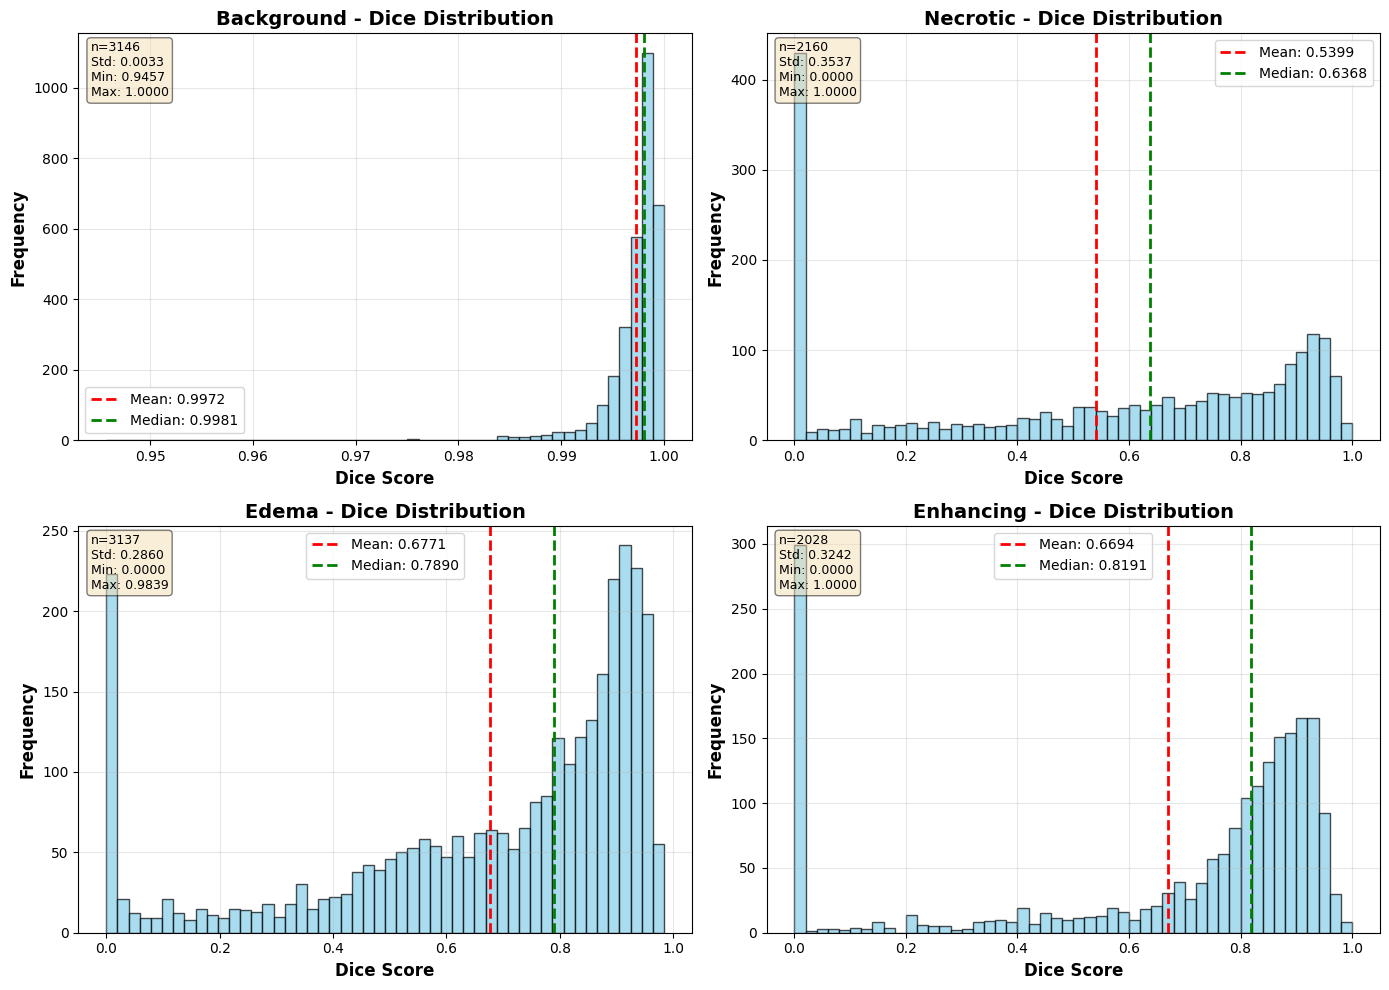


DICE DISTRIBUTION STATISTICS
     Class  Count   Mean  Median    Std    Min    Max     Q1     Q3
Background   3146 0.9972  0.9981 0.0033 0.9457 1.0000 0.9967 0.9988
  Necrotic   2160 0.5399  0.6368 0.3537 0.0000 1.0000 0.1838 0.8694
     Edema   3137 0.6771  0.7890 0.2860 0.0000 0.9839 0.5405 0.9005
 Enhancing   2028 0.6694  0.8191 0.3242 0.0000 1.0000 0.5714 0.8943
✅ Dice distribution plotted!


In [53]:
# Cell 22: Dice Distribution per Class

def plot_class_dice_distribution(model, dataloader, device, save_path):
    """Plot Dice score distribution per class"""
    
    model.eval()
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    dice_per_class = [[] for _ in range(4)]
    
    print("Computing per-sample Dice scores...")
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Computing Dice'):
            images = images.to(device)
            
            with autocast(enabled=config.MIXED_PRECISION):
                outputs = model(images)
            
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            masks_np = masks.cpu().numpy()
            
            # Compute dice for each sample
            for i in range(len(images)):
                for c in range(4):
                    pred_c = (preds[i] == c).astype(np.float32)
                    true_c = (masks_np[i] == c).astype(np.float32)
                    
                    intersection = np.sum(pred_c * true_c)
                    union = np.sum(pred_c) + np.sum(true_c)
                    
                    if union > 0:
                        dice = (2 * intersection) / union
                        dice_per_class[c].append(dice)
    
    # Plot distributions
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for c in range(4):
        dice_scores = np.array(dice_per_class[c])
        
        axes[c].hist(dice_scores, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        
        mean_dice = np.mean(dice_scores)
        median_dice = np.median(dice_scores)
        
        axes[c].axvline(mean_dice, color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {mean_dice:.4f}')
        axes[c].axvline(median_dice, color='green', linestyle='--', linewidth=2, 
                       label=f'Median: {median_dice:.4f}')
        
        axes[c].set_xlabel('Dice Score', fontsize=12, fontweight='bold')
        axes[c].set_ylabel('Frequency', fontsize=12, fontweight='bold')
        axes[c].set_title(f'{class_names[c]} - Dice Distribution', 
                         fontsize=14, fontweight='bold')
        axes[c].legend(fontsize=10)
        axes[c].grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f'n={len(dice_scores)}\nStd: {np.std(dice_scores):.4f}\n'
        stats_text += f'Min: {np.min(dice_scores):.4f}\nMax: {np.max(dice_scores):.4f}'
        axes[c].text(0.02, 0.98, stats_text, transform=axes[c].transAxes,
                    verticalalignment='top', bbox=dict(boxstyle='round', 
                    facecolor='wheat', alpha=0.5), fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'dice_distribution.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # Save statistics
    dice_stats = []
    for c in range(4):
        dice_scores = np.array(dice_per_class[c])
        dice_stats.append({
            'Class': class_names[c],
            'Count': len(dice_scores),
            'Mean': np.mean(dice_scores),
            'Median': np.median(dice_scores),
            'Std': np.std(dice_scores),
            'Min': np.min(dice_scores),
            'Max': np.max(dice_scores),
            'Q1': np.percentile(dice_scores, 25),
            'Q3': np.percentile(dice_scores, 75)
        })
    
    df_stats = pd.DataFrame(dice_stats)
    df_stats.to_csv(os.path.join(save_path, 'dice_statistics.csv'), index=False)
    
    print("\n" + "="*70)
    print("DICE DISTRIBUTION STATISTICS")
    print("="*70)
    print(df_stats.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    print("="*70)


plot_class_dice_distribution(model, test_loader, device, config.SAVE_PATH)

print("✅ Dice distribution plotted!")